#**Box Office Intelligence: Data-Driven Insights for a New Movie Studio**



##**Introduction**

As we prepare to launch our own movie studio, we recognized the need to understand what makes films successful at the box office. We analyzed recent movie performance data to uncover the genres, budgets, and audience preferences that drive both revenue and ratings. Our goal was to translate these findings into clear, actionable insights that will guide our studio’s decisions on which types of films to develop and how to allocate production budgets effectively.

####**Business Questions We Explored**

1.   **Which genres are currently delivering the highest box office revenue?**
        We wanted to pinpoint the most financially promising types of films to help focus our investments.

2.   **How do production budgets and genre choices interact to impact revenue?**
        We needed to understand whether spending more in certain genres produces higher returns.

3.  **Which genres earn the highest audience ratings and which genres strike the best balance between ratings and revenue?**
        We set out to identify the types of films that are not only profitable but also positively received by audiences, ensuring long-term brand value for our studio.

**Step 0: Import the necessary libraries**

In [2]:
# --- IMPORTS ---
%matplotlib inline
import pandas as pd
import numpy as np
import statsmodels.api as sm
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display



**Step 1: Load data**

In [3]:
df = pd.read_csv("/content/Merged data.csv")

**Step 2: Clean Numeric Columns**

Defines a helper clean_money to:

*   Remove “$” and commas from strings.
*   Convert cleaned strings to numeric values.
*   Coerce invalid entries to NaN.

Applies it to money-related columns to make sure they’re numbers instead of text.


In [4]:
# --- STEP 2: CLEAN NUMERIC COLUMNS ---
def clean_money(x):
    if isinstance(x, str):
        return pd.to_numeric(x.replace("$","").replace(",","").strip(), errors='coerce')
    return pd.to_numeric(x, errors='coerce')

for col in ["worldwide_gross", "domestic_gross_y", "production_budget"]:
    df[col] = df[col].apply(clean_money)

**Step 3: Map Genre Codes to Names**

Created a dictionry linking the genre id to readable names. ie Horror, Action
The map_genre function converts the string "[28, 12]" into a python list then maps each code to it's name. We then add a new column genre that has the actual names as lists.

In [5]:
 #--- STEP 3: MAP GENRE CODES TO NAMES ---
genre_map = {
    28: "Action", 12: "Adventure", 16: "Animation", 35: "Comedy",
    80: "Crime", 99: "Documentary", 18: "Drama", 10751: "Family",
    14: "Fantasy", 36: "History", 27: "Horror", 10402: "Music",
    9648: "Mystery", 10749: "Romance", 878: "Science Fiction",
    10770: "TV Movie", 53: "Thriller", 10752: "War", 37: "Western"
}

def map_genres(genre_str):
    try:
        genre_list = ast.literal_eval(genre_str)
        return [genre_map.get(g, "Unknown") for g in genre_list]
    except:
        return []

df["genres"] = df["genre_ids"].apply(map_genres)

# --- STEP 4: EXPLODE GENRES AND CREATE DUMMIES ---
df_exploded = df.explode("genres")
df_encoded = pd.get_dummies(df_exploded, columns=["genres"], drop_first=True)


**Step 4: Explode Genres and Create Dummies**

We want genre indicators in numeric form for regressions and plots.

*   Explode ("Genre"): Creates on row per movie, genre paire instead of having a list of genre in one cell
*   pd.get_dummies: One-hot encodes genres into binary columns (0/1 for each genre). drop_first=True avoids multicollinearity by dropping one dummy column per category.





In [ ]:
# --- STEP 4: EXPLODE GENRES AND CREATE DUMMIES ---
df_exploded = df.explode("genres")
df_encoded = pd.get_dummies(df_exploded, columns=["genres"], drop_first=True)

**Step 5: Revenue Regression (Revenue ~ Genres + Budget)**

Here we model box-office revenue as a function of production budget and genre indicators to estimate how much being in a genre (and budget level) is associated with revenue. statsmodels.OLS provides coefficients, standard errors and p-values we can interpret for business decisions.


*   Drop irrelevant columns so only predictors remain.
*   Remove rows with missing data.
*   Add an intercept column.
*   Shows regression summary.



In [8]:
# --- STEP 5: REVENUE REGRESSION (Revenue ~ Genres + Budget) ---
drop_cols = ["title","studio","foreign_gross","release_date",
             "movie","domestic_gross_x","id_x","id_y",
             "Unnamed: 0","genre_ids","original_language",
             "original_title","worldwide_gross","vote_average",
             "vote_count","popularity","year","domestic_gross_y"]

X1 = df_encoded.drop(columns=drop_cols).apply(pd.to_numeric, errors='coerce')
y1 = pd.to_numeric(df_encoded["worldwide_gross"], errors='coerce')
# Drop rows with NaNs
mask1 = X1.notna().all(axis=1) & y1.notna()
X1 = X1.loc[mask1, :].astype(float)
y1 = y1.loc[mask1].astype(float)

X1 = sm.add_constant(X1, has_constant='add')
model1 = sm.OLS(y1, X1).fit()

print("=== Revenue Regression Summary ===")
display(model1.summary())


=== Revenue Regression Summary ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        worldwide_gross   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     227.0
Date:                Sat, 13 Sep 2025   Prob (F-statistic):               0.00
Time:                        11:40:17   Log-Likelihood:                -54003.
No. Observations:                2649   AIC:                         1.080e+05
Df Residuals:                    2630   BIC:                         1.082e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -8.6e+06   1.17e+07     -0.737      0.461   -3.15e+07    1.43e+07
production_budget          3.3172      0.062     53.318      0.000       3.195       3.439
genres_Adventure        2.296e+07   1.57e+07      1.466      0.143   -7.75e+06    5.37e+07
genres_Animation        7.628e+07    2.2e+07      3.468      0.001    3.32e+07    1.19e+08
genres_Comedy           2.184e+07    1.4e+07      1.564      0.118   -5.54e+06    4.92e+07
genres_Crime           -9.564e+06   1.83e+07     -0.524      0.600   -4.54e+07    2.62e+07
genres_Documentary      2.151e+07   7.84e+07      0.275      0.784   -1.32e+08    1.75e+08
genres_Drama           -9.109e+05   1.35e+07     -0.068      0.946   -2.73e+07    2.55e+07
genres_Family           1.955e+07   1.85e+07      1.058      0.290   -1.67e+07    5.58e+07
genres_Fantasy         -5.535e+06   1.89e+07     -0.293      0.769   -4.26e+07    3.15e+07
genres_History         -3.916e+07   2.75e+07     -1.426      0.154    -9.3e+07    1.47e+07
genres_Horror           3.603e+07   1.96e+07      1.839      0.066   -2.38e+06    7.44e+07
genres_Music             1.88e+07   3.34e+07      0.563      0.574   -4.67e+07    8.43e+07
genres_Mystery          8.087e+06   2.32e+07      0.348      0.728   -3.75e+07    5.37e+07
genres_Romance          5.987e+06   1.85e+07      0.323      0.746   -3.03e+07    4.23e+07
genres_Science Fiction  1.353e+07   1.85e+07      0.732      0.464   -2.27e+07    4.98e+07
genres_Thriller         1.248e+06   1.49e+07      0.084      0.933   -2.79e+07    3.04e+07
genres_War              1.247e+06   3.84e+07      0.032      0.974    -7.4e+07    7.65e+07
genres_Western          -1.11e+07   4.75e+07     -0.234      0.815   -1.04e+08     8.2e+07
==============================================================================
Omnibus:                     1055.360   Durbin-Watson:                   0.380
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7795.930
Skew:                           1.705   Prob(JB):                         0.00
Kurtosis:                      10.682   Cond. No.                     2.06e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.06e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Step 6: Ratings regression (Ratings ~ Genres Only)**

We want to see how genre composition correlates with audience ratings independent of budget. This helps answer which genre types tend to be better received.

In [9]:
# --- STEP 6: RATINGS REGRESSION (Ratings ~ Genres Only) ---
genre_cols = [col for col in df_encoded.columns if col.startswith("genres_")]
X2 = df_encoded[genre_cols].apply(pd.to_numeric, errors='coerce')
y2 = pd.to_numeric(df_encoded["vote_average"], errors='coerce')

mask2 = X2.notna().all(axis=1) & y2.notna()
X2 = X2.loc[mask2, :].astype(float)
y2 = y2.loc[mask2].astype(float)

X2 = sm.add_constant(X2, has_constant='add')
model2 = sm.OLS(y2, X2).fit()

print("=== Ratings Regression Summary ===")
display(model2.summary())

=== Ratings Regression Summary ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           vote_average   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     11.87
Date:                Sat, 13 Sep 2025   Prob (F-statistic):           2.91e-32
Time:                        11:40:25   Log-Likelihood:                -3015.4
No. Observations:                2649   AIC:                             6067.
Df Residuals:                    2631   BIC:                             6173.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6.3521      0.044    143.220      0.000       6.265       6.439
genres_Adventure           0.1618      0.068      2.379      0.017       0.028       0.295
genres_Animation           0.2277      0.096      2.369      0.018       0.039       0.416
genres_Comedy             -0.0570      0.060     -0.957      0.339      -0.174       0.060
genres_Crime               0.1428      0.079      1.815      0.070      -0.011       0.297
genres_Documentary         0.2879      0.342      0.842      0.400      -0.382       0.958
genres_Drama               0.3433      0.056      6.092      0.000       0.233       0.454
genres_Family              0.0575      0.081      0.711      0.477      -0.101       0.216
genres_Fantasy            -0.0067      0.082     -0.081      0.935      -0.168       0.155
genres_History             0.4288      0.119      3.600      0.000       0.195       0.662
genres_Horror             -0.5668      0.083     -6.794      0.000      -0.730      -0.403
genres_Music               0.1613      0.145      1.110      0.267      -0.124       0.446
genres_Mystery            -0.0183      0.100     -0.182      0.856      -0.215       0.178
genres_Romance             0.1731      0.079      2.195      0.028       0.018       0.328
genres_Science Fiction     0.1646      0.081      2.038      0.042       0.006       0.323
genres_Thriller           -0.0983      0.063     -1.549      0.121      -0.223       0.026
genres_War                 0.4116      0.168      2.456      0.014       0.083       0.740
genres_Western             0.3908      0.207      1.885      0.060      -0.016       0.797
==============================================================================
Omnibus:                        9.077   Durbin-Watson:                   0.727
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                9.089
Skew:                          -0.132   Prob(JB):                       0.0106
Kurtosis:                       2.888   Cond. No.                         24.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Step 7: Significant genres only (p < 0.05)**

Here we identify which genres have statistically significant associations with revenue or ratings so leadership can focus on meaningful effects, not noise.

In [10]:
# --- STEP 7: SIGNIFICANT GENRES ONLY (p < 0.05) ---
def significant_coeffs(model, top_n=10):
    df_coef = pd.DataFrame({
        'coef': model.params,
        'pval': model.pvalues
    })
    df_sig = df_coef[df_coef['pval'] < 0.05].sort_values('coef', ascending=False)
    return df_sig.head(top_n)

print("\nTop 10 Significant Genre Effects on Revenue:")
display(significant_coeffs(model1))

print("\nTop 10 Significant Genre Effects on Ratings:")
display(significant_coeffs(model2))



Top 10 Significant Genre Effects on Revenue:


,coef,pval
genres_Animation,7.627937e+07,0.000532
production_budget,3.317243e+00,0.000000



Top 10 Significant Genre Effects on Ratings:


,coef,pval
const,6.352055,0.000000e+00
genres_History,0.428796,3.242399e-04
genres_War,0.411582,1.409967e-02
genres_Drama,0.343314,1.281739e-09
genres_Animation,0.227692,1.790865e-02
genres_Romance,0.173130,2.825787e-02
genres_Science Fiction,0.164612,4.167674e-02
genres_Adventure,0.161834,1.741536e-02
genres_Horror,-0.566837,1.347674e-11


**Step 8: Visualization (Top 20 genres by revenue & by rating)**

Showing **top genres** by mean revenue and by mean rating highlights where the company could prioritize development.

/tmp/ipython-input-3658281365.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_revenue.index, y=avg_revenue.values, palette="viridis")


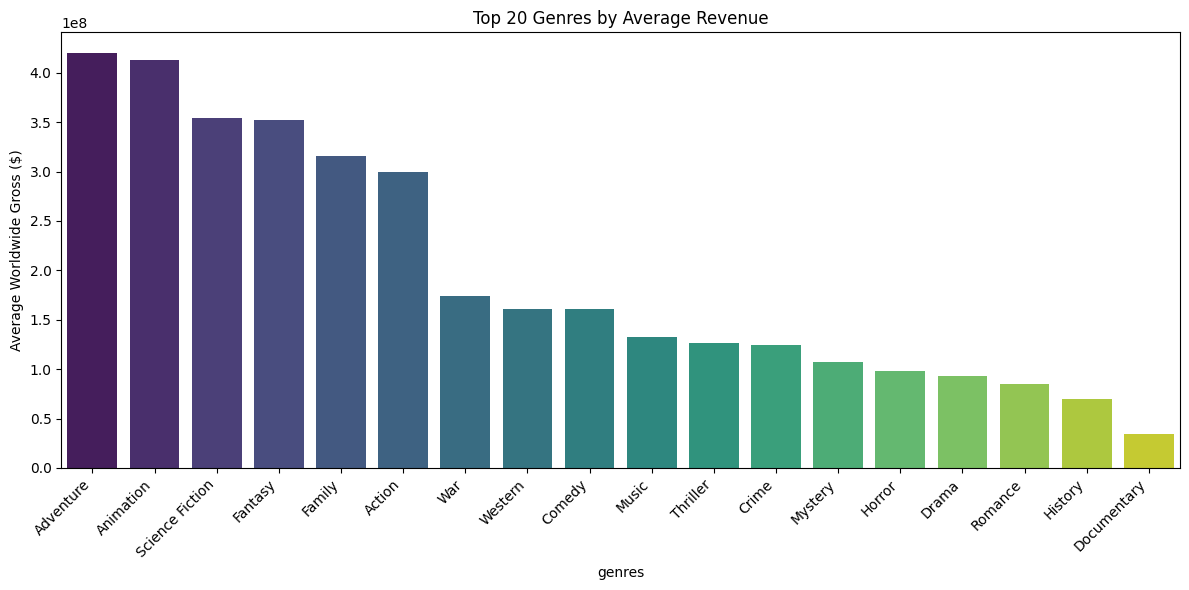

/tmp/ipython-input-3658281365.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="magma")


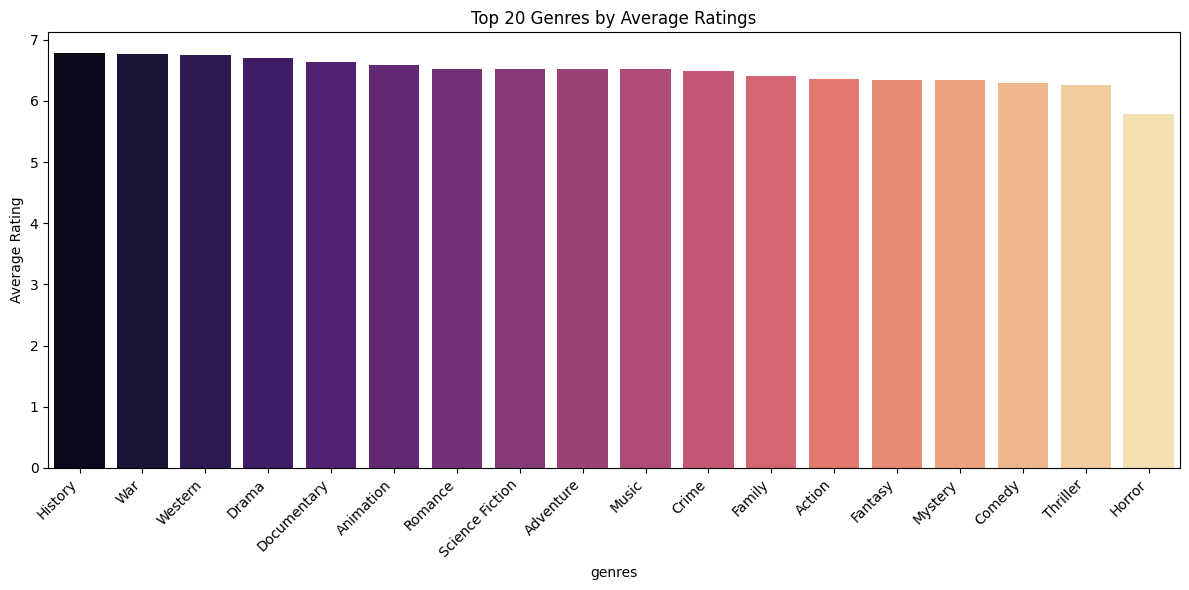

In [11]:
# --- STEP 8: VISUALIZATION ---
# Filter exploded df to numeric values only
df_vis = df_exploded[df_exploded["worldwide_gross"].notna() & df_exploded["vote_average"].notna()]

# Top 20 genres by average revenue
avg_revenue = df_vis.groupby("genres")["worldwide_gross"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_revenue.index, y=avg_revenue.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Worldwide Gross ($)")
plt.title("Top 20 Genres by Average Revenue")
plt.tight_layout()
plt.show()

# Top 20 genres by average rating
avg_rating = df_vis.groupby("genres")["vote_average"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="magma")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Rating")
plt.title("Top 20 Genres by Average Ratings")
plt.tight_layout()
plt.show()

**Step 9: Combined plots for revenue and ratings**

This shows how revenue and rating compare for the same genres.


*   Selects top 15 genres by both metrics.
*   Creates a combined dataset with mean revenue and rating.
*   Plots bars for average revenue (green) and overlays a red line for average rating.



/tmp/ipython-input-134083584.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data["worldwide_gross"], palette="viridis", ax=ax1)
/tmp/ipython-input-134083584.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plot_data.index, rotation=45, ha='right')


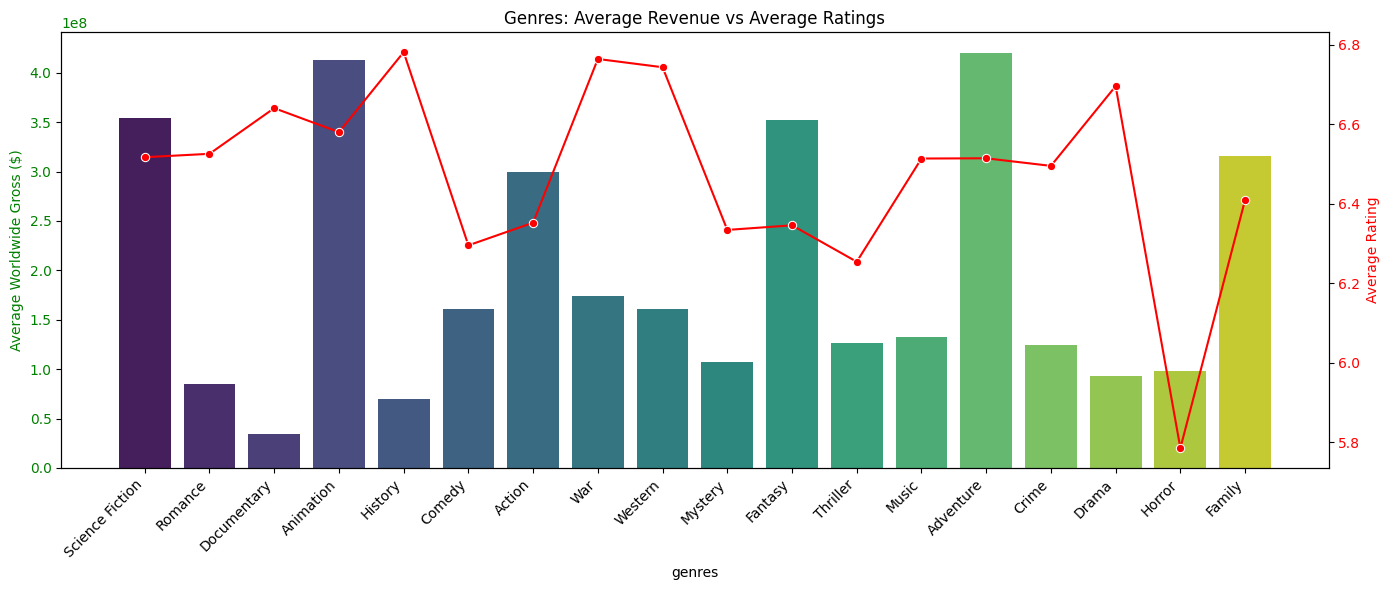

In [12]:
# --- STEP 9: COMBINED PLOTS FOR REVENUE AND RATINGS ---

# Filter exploded df to numeric values only
df_vis = df_exploded[df_exploded["worldwide_gross"].notna() & df_exploded["vote_average"].notna()]

# Compute top 15 genres by average revenue
top_revenue_genres = df_vis.groupby("genres")["worldwide_gross"].mean().sort_values(ascending=False).head(15)
top_rating_genres = df_vis.groupby("genres")["vote_average"].mean().sort_values(ascending=False).head(15)

# Combine unique top genres
combined_genres = list(set(top_revenue_genres.index) | set(top_rating_genres.index))

# Prepare data for plotting
plot_data = df_vis[df_vis["genres"].isin(combined_genres)].groupby("genres").agg({
    "worldwide_gross": "mean",
    "vote_average": "mean"
}).reindex(combined_genres)

# Plot side by side
fig, ax1 = plt.subplots(figsize=(14,6))

# Revenue bars
sns.barplot(x=plot_data.index, y=plot_data["worldwide_gross"], palette="viridis", ax=ax1)
ax1.set_ylabel("Average Worldwide Gross ($)", color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xticklabels(plot_data.index, rotation=45, ha='right')

# Rating line on secondary y-axis
ax2 = ax1.twinx()
sns.lineplot(x=plot_data.index, y=plot_data["vote_average"], color='red', marker='o', ax=ax2)
ax2.set_ylabel("Average Rating", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Genres: Average Revenue vs Average Ratings")
plt.tight_layout()
plt.show()
